In [430]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')


In [431]:
train_data=pd.read_csv("Train_dataset.csv")
test_data=pd.read_csv("Test_dataset.csv")

In [432]:
train_data.head()

,SEQN,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,age_group
0,73564.0,2.0,2.0,35.7,110.0,2.0,150.0,14.91,Adult
1,73568.0,2.0,2.0,20.3,89.0,2.0,80.0,3.85,Adult
2,73576.0,1.0,2.0,23.2,89.0,2.0,68.0,6.14,Adult
3,73577.0,1.0,2.0,28.9,104.0,NaN,84.0,16.15,Adult
4,73580.0,2.0,1.0,35.9,103.0,2.0,81.0,10.92,Adult


In [433]:
test_data.head()

,SEQN,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN
0,77017.0,1.0,1.0,32.2,96.0,2.0,135.0,15.11
1,75580.0,2.0,2.0,26.3,100.0,2.0,141.0,15.26
2,73820.0,1.0,2.0,28.6,107.0,2.0,136.0,8.82
3,80489.0,2.0,1.0,22.1,93.0,2.0,111.0,12.13
4,82047.0,1.0,1.0,24.7,91.0,2.0,105.0,3.12


In [434]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1966 entries, 0 to 1965
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SEQN       1954 non-null   float64
 1   RIAGENDR   1948 non-null   float64
 2   PAQ605     1953 non-null   float64
 3   BMXBMI     1948 non-null   float64
 4   LBXGLU     1953 non-null   float64
 5   DIQ010     1948 non-null   float64
 6   LBXGLT     1955 non-null   float64
 7   LBXIN      1957 non-null   float64
 8   age_group  1952 non-null   object 
dtypes: float64(8), object(1)
memory usage: 138.4+ KB


In [435]:
train_data.shape

(1966, 9)

In [436]:
train_data.isnull().sum()

SEQN         12
RIAGENDR     18
PAQ605       13
BMXBMI       18
LBXGLU       13
DIQ010       18
LBXGLT       11
LBXIN         9
age_group    14
dtype: int64

In [437]:
train_data.describe()

,SEQN,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN
count,1954.000000,1948.000000,1953.000000,1948.000000,1953.000000,1948.000000,1955.000000,1957.000000
mean,78683.621801,1.510267,1.825397,27.965400,99.491039,2.015914,115.150384,11.862892
std,2924.115709,0.500023,0.399449,7.327616,16.774665,0.187579,46.271615,9.756713
min,73564.000000,1.000000,1.000000,14.500000,63.000000,1.000000,40.000000,0.140000
25%,76194.000000,1.000000,2.000000,22.800000,91.000000,2.000000,87.000000,5.800000
50%,78717.000000,2.000000,2.000000,26.800000,97.000000,2.000000,105.000000,9.030000
75%,81217.000000,2.000000,2.000000,31.300000,104.000000,2.000000,131.000000,14.480000
max,83727.000000,2.000000,7.000000,70.100000,405.000000,3.000000,604.000000,102.290000


In [438]:
train_data.duplicated().sum()


np.int64(0)

In [439]:
train_data = train_data.dropna(subset=['age_group'])
train_data['age_group'] = train_data['age_group'].map({
    'Adult':0,
    'Senior':1
})

In [440]:
train_data.columns

Index(['SEQN', 'RIAGENDR', 'PAQ605', 'BMXBMI', 'LBXGLU', 'DIQ010', 'LBXGLT',
       'LBXIN', 'age_group'],
      dtype='object')

In [441]:
train_data = train_data.dropna(subset=["SEQN"])
test_data = train_data.dropna(subset=["SEQN"])

<Axes: xlabel='age_group', ylabel='count'>

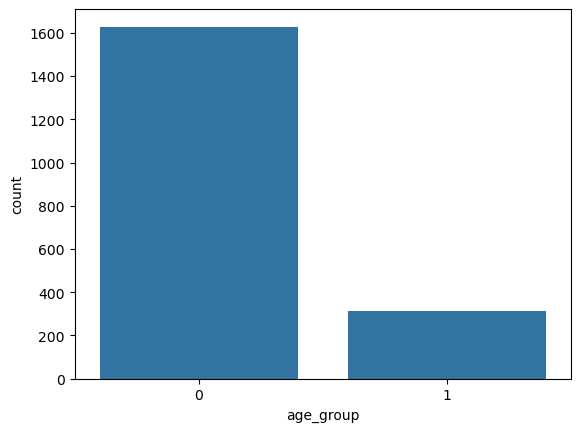

In [442]:
train_data['age_group'].value_counts()

import seaborn as sns
sns.countplot(x='age_group', data=train_data)

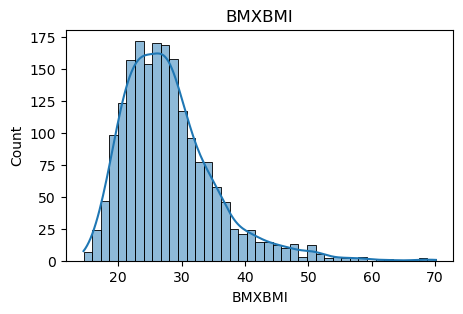

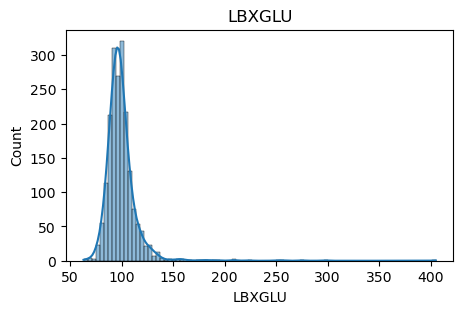

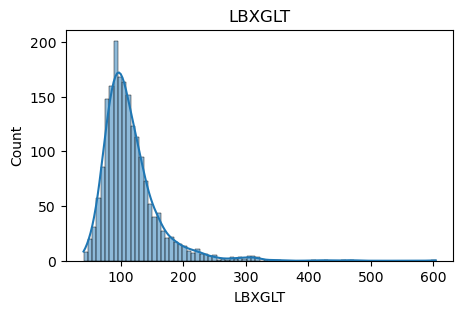

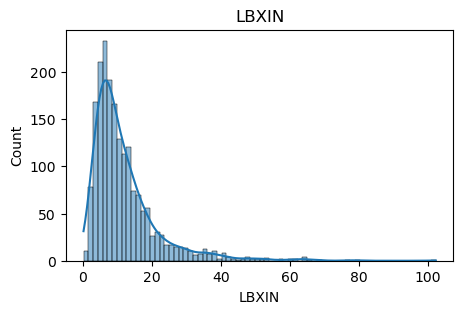

In [443]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['BMXBMI','LBXGLU','LBXGLT','LBXIN']

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(train_data[col], kde=True)
    plt.title(col)
    plt.show()

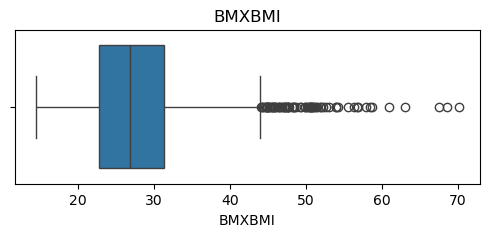

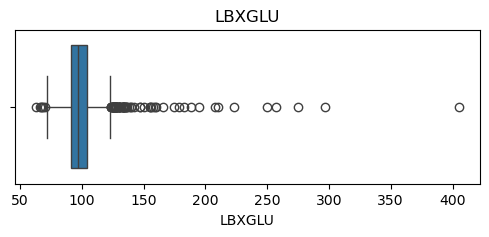

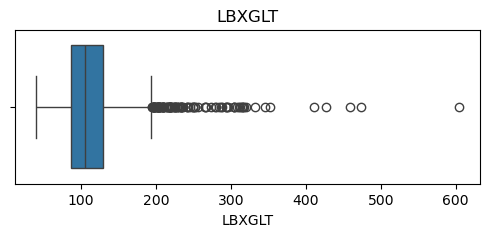

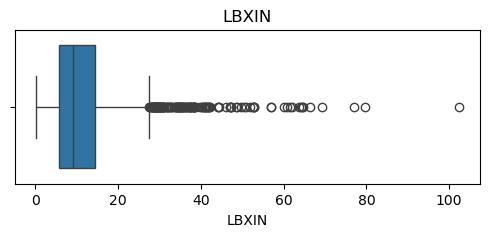

In [444]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['BMXBMI','LBXGLU','LBXGLT','LBXIN']

for col in num_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=train_data[col])
    plt.title(col)
    plt.show()

In [445]:
num_cols = ['BMXBMI','LBXGLU','LBXGLT','LBXIN']

for col in num_cols:
    train_data[col].fillna(train_data[col].median(), inplace=True)

cat_cols = ['RIAGENDR','PAQ605','DIQ010']

for col in cat_cols:
    train_data[col].fillna(train_data[col].mode()[0], inplace=True)

In [446]:
train_data.drop('SEQN', axis=1, inplace=True)
test_data.drop('SEQN', axis=1, inplace=True)

In [447]:
train_data.isnull().sum()

RIAGENDR     0
PAQ605       0
BMXBMI       0
LBXGLU       0
DIQ010       0
LBXGLT       0
LBXIN        0
age_group    0
dtype: int64

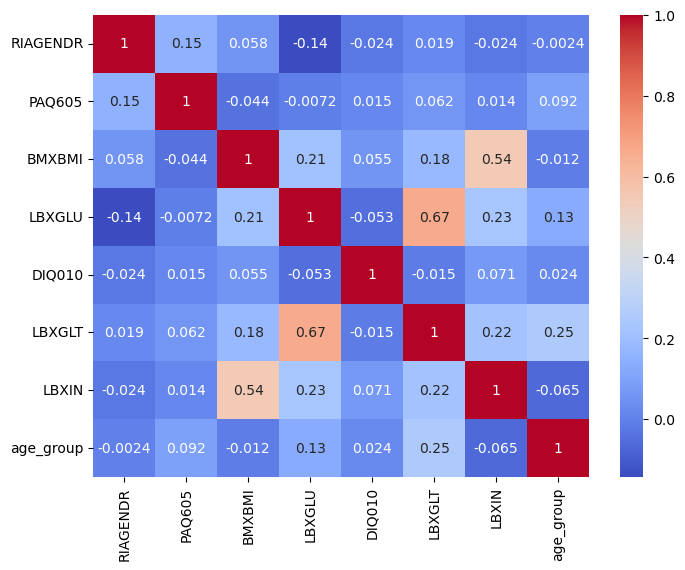

In [448]:
plt.figure(figsize=(8,6))

sns.heatmap(
    train_data.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

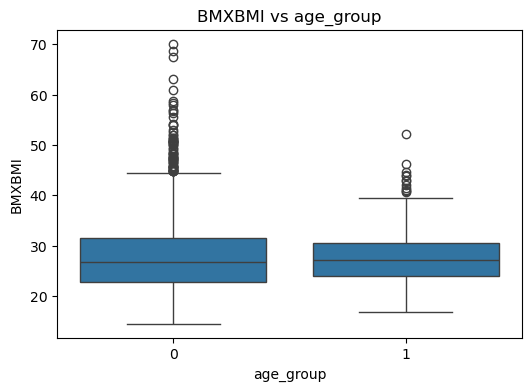

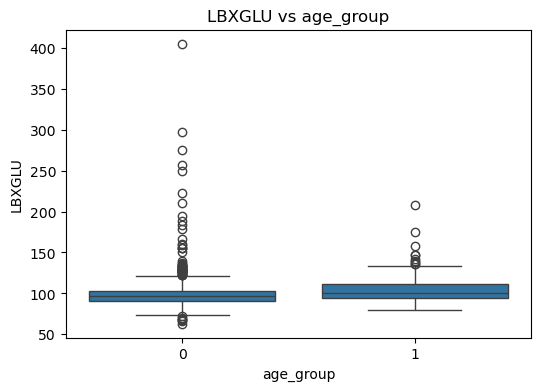

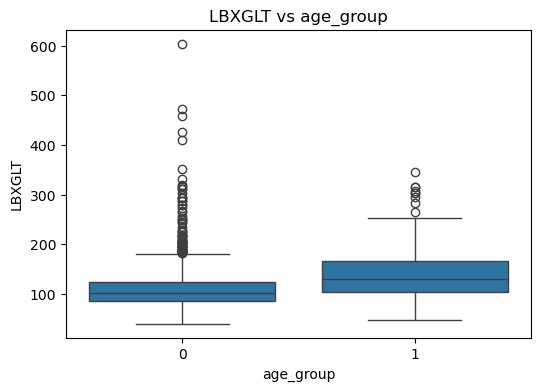

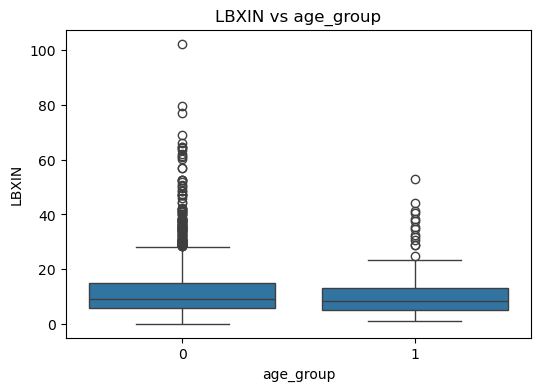

In [449]:

import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['BMXBMI', 'LBXGLU', 'LBXGLT', 'LBXIN']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='age_group', y=col, data=train_data)
    plt.title(f'{col} vs age_group')
    plt.show()

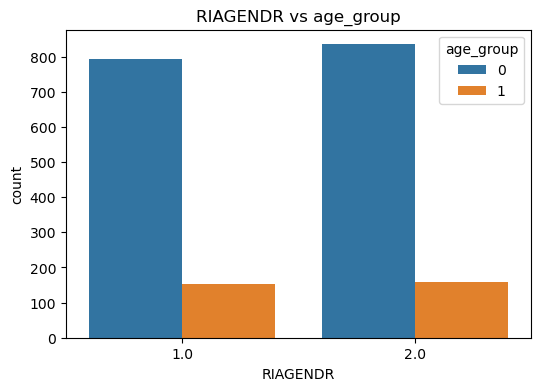

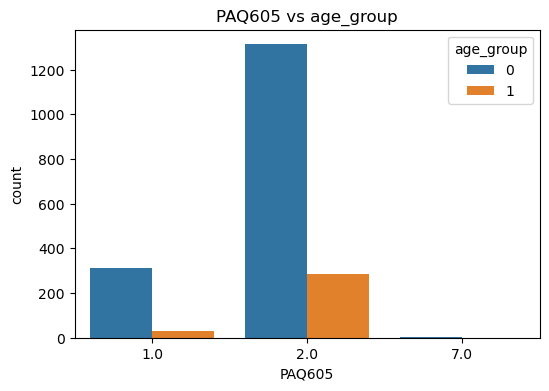

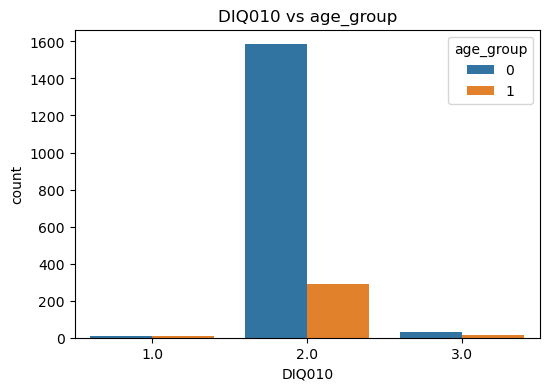

In [450]:
import matplotlib.pyplot as plt
import seaborn as sns

cat_cols = ['RIAGENDR', 'PAQ605', 'DIQ010']

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='age_group', data=train_data)
    plt.title(f'{col} vs age_group')
    plt.show()

In [451]:
print(train_data['PAQ605'].value_counts())
print(train_data['DIQ010'].value_counts())
print(train_data['RIAGENDR'].value_counts())

PAQ605
2.0    1597
1.0     342
7.0       1
Name: count, dtype: int64
DIQ010
2.0    1872
3.0      49
1.0      19
Name: count, dtype: int64
RIAGENDR
2.0    994
1.0    946
Name: count, dtype: int64


In [452]:
train_data['PAQ605'].value_counts()

PAQ605
2.0    1597
1.0     342
7.0       1
Name: count, dtype: int64

In [453]:
train_data['PAQ605'] = train_data['PAQ605'].replace(7, 2)

test_data['PAQ605'] = test_data['PAQ605'].replace(7, 2)

In [454]:
train_data['BMI_Category'] = pd.cut(
    train_data['BMXBMI'],
    bins=[0,18.5,25,30,100],
    labels=[0,1,2,3]
)

test_data['BMI_Category'] = pd.cut(
    test_data['BMXBMI'],
    bins=[0,18.5,25,30,100],
    labels=[0,1,2,3]
)

In [455]:
train_data['High_BMI'] = (train_data['BMXBMI'] >= 30).astype(int)
test_data['High_BMI'] = (test_data['BMXBMI'] >= 30).astype(int)

In [456]:
train_data['High_Glucose'] = (train_data['LBXGLU'] >= 126).astype(int)
test_data['High_Glucose'] = (test_data['LBXGLU'] >= 126).astype(int)

In [457]:
train_data['BMI_GLU'] = train_data['BMXBMI'] * train_data['LBXGLU']
test_data['BMI_GLU'] = test_data['BMXBMI'] * test_data['LBXGLU']

In [458]:
X = train_data.drop('age_group', axis=1)
y = train_data['age_group']

In [459]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [460]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [461]:
from sklearn.metrics import accuracy_score

pred = model.predict(X_val)

accuracy_score(y_val, pred)

0.8298969072164949

In [462]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

pred = dt.predict(X_val)

accuracy_score(y_val, pred)

0.7603092783505154

In [463]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred = rf.predict(X_val)

accuracy_score(y_val, pred)

0.845360824742268

In [464]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

         Feature  Importance
5         LBXGLT    0.241614
6          LBXIN    0.186922
10       BMI_GLU    0.176670
2         BMXBMI    0.156940
3         LBXGLU    0.151200
0       RIAGENDR    0.023393
1         PAQ605    0.019132
7   BMI_Category    0.017063
4         DIQ010    0.014074
8       High_BMI    0.007565
9   High_Glucose    0.005430


In [465]:
!pip install xgboost

In [466]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_val)

print("XGBoost Accuracy:", accuracy_score(y_val, xgb_pred))
print(confusion_matrix(y_val, xgb_pred))
print(classification_report(y_val, xgb_pred))

XGBoost Accuracy: 0.8247422680412371
[[315  11]
 [ 57   5]]
              precision    recall  f1-score   support

           0       0.85      0.97      0.90       326
           1       0.31      0.08      0.13        62

    accuracy                           0.82       388
   macro avg       0.58      0.52      0.52       388
weighted avg       0.76      0.82      0.78       388



In [467]:
print(train_data['age_group'].value_counts())

age_group
0    1628
1     312
Name: count, dtype: int64


0.8092783505154639


In [469]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score: 0.8479390104760917


In [470]:
 best_rf = grid.best_estimator_

 pred = best_rf.predict(X_val)

 from sklearn.metrics import accuracy_score
 print("Validation Accuracy:", accuracy_score(y_val, pred))

Validation Accuracy: 0.8376288659793815


In [471]:

X = train_data.drop(
    ['age_group', 'High_BMI', 'High_Glucose', 'BMI_Category'],
    axis=1
)

X_test = test_data.drop(
    ['High_BMI', 'High_Glucose', 'BMI_Category'],
    axis=1
)

In [472]:
from sklearn.ensemble import RandomForestClassifier

X = train_data.drop('age_group', axis=1)
y = train_data['age_group']

rf = RandomForestClassifier(random_state=42)

rf.fit(X, y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# useful feature only
train_data['BMI_GLU'] = train_data['BMXBMI'] * train_data['LBXGLU']
test_data['BMI_GLU'] = test_data['BMXBMI'] * test_data['LBXGLU']

# drop unwanted columns safely
drop_cols_train = ['age_group', 'SEQN', 'BMI_Category', 'High_BMI', 'High_Glucose']
drop_cols_test = ['SEQN', 'BMI_Category', 'High_BMI', 'High_Glucose']

X = train_data.drop(columns=[c for c in drop_cols_train if c in train_data.columns])
y = train_data['age_group']

test_final = test_data.drop(columns=[c for c in drop_cols_test if c in test_data.columns])

# make exact same column order
test_final = test_final[X.columns]

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

test_pred = rf.predict(test_final)

submission = pd.DataFrame({
    "age_group": test_pred
})

print(submission.shape)
submission.to_csv("submission.csv", index=False)

In [ ]:

print(test_data.shape)

print(submission.head())

print(submission['age_group'].value_counts())

print(train_data.columns)
print(test_data.columns)

In [ ]:
test_data = test_data.drop(columns=['SEQN'])


test_data = test_data[X.columns]

In [476]:

print(X.columns)
print(test_data.columns)


Index(['RIAGENDR', 'PAQ605', 'BMXBMI', 'LBXGLU', 'DIQ010', 'LBXGLT', 'LBXIN',
       'BMI_GLU'],
      dtype='object')
Index(['RIAGENDR', 'PAQ605', 'BMXBMI', 'LBXGLU', 'DIQ010', 'LBXGLT', 'LBXIN',
       'age_group', 'BMI_Category', 'High_BMI', 'High_Glucose', 'BMI_GLU'],
      dtype='object')


In [477]:
test_data = pd.read_csv("Test_dataset.csv")   # Use your exact filename

In [478]:
# Drop identifier
test_data.drop(columns='SEQN', inplace=True)

# Fill missing values (same way as train)
# Example:
# test_data['LBXGLU'].fillna(train_data['LBXGLU'].median(), inplace=True)
# ...

# Create only the feature you decided to keep
test_data['BMI_GLU'] = test_data['BMXBMI'] * test_data['LBXGLU']

# Make column order identical
test_data = test_data[X.columns]

In [485]:
print(test_data.shape)
print(test_data.columns)

(312, 8)
Index(['RIAGENDR', 'PAQ605', 'BMXBMI', 'LBXGLU', 'DIQ010', 'LBXGLT', 'LBXIN',
       'BMI_GLU'],
      dtype='object')


In [486]:
print(X.columns)

Index(['RIAGENDR', 'PAQ605', 'BMXBMI', 'LBXGLU', 'DIQ010', 'LBXGLT', 'LBXIN',
       'BMI_GLU'],
      dtype='object')


In [488]:

test_pred = rf.predict(test_data)

submission = pd.DataFrame({
    "age_group": test_pred
})

print(submission.shape)
submission.to_csv("submission.csv", index=False)

(312, 1)


In [489]:
submission['age_group'].value_counts()

age_group
0    297
1     15
Name: count, dtype: int64